In [1]:
from dataloader import *
from augmentations import *
from models import *
from training import *
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from statistics import mean, stdev
import copy
import ast
import seaborn as sns

## Models

In [2]:
models = ["SmallCNN", 
          "ResNet",
          "DenseNet121", 
          "VGG16_BN", 
           ]

## Experiment loop for hyperparameter selection 

In [3]:
# choosing hyperparameters for grid search
params = {
    "batch_size": [8, 32, 128],
    "learning_rate": [1e-3, 1e-4, 1e-5],
    "optimizer": ['Adam', 'SGD'],
    "dropout": [0.2, 0.5],
    "weight_decay": [0, 1e-3, 0.5]
}

experiment_grid = [dict(zip(params.keys(), v)) for v in product(*params.values())]

In [4]:
def run_experiment(model_name, experiment_config, augmentation=None, cutmix_collate_fn=None, epoch_number=2, train_size=9000, test_size=9000):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # model
    current_dropout = experiment_config.get("dropout", 0.2)
    model = get_model(model_name, dropout_rate=current_dropout)   
    model.to(device)

    # optimizer
    if experiment_config["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=experiment_config["learning_rate"],
            weight_decay=experiment_config["weight_decay"]
        )
    else:
        optimizer = torch.optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=experiment_config["learning_rate"],
            weight_decay=experiment_config["weight_decay"],
            momentum=0.9
        )

    transformations = basic_transforms(augmentation_type=augmentation, model_type=model_name)

    train_dataset = get_train_dataset(transform=transformations)
    val_dataset, test_dataset = get_val_train_dataset(model_type=model_name)

    train_dataset = get_subset(train_dataset, train_size)
    val_dataset = get_subset(val_dataset, test_size)
    test_dataset = get_subset(test_dataset, test_size)

    train_loader = get_train_dataloaders(
        train_dataset,
        collate_fn=cutmix_collate_fn,
        batch_size=experiment_config["batch_size"]
    )
    
    val_loader, test_loader = get_val_test_dataloaders(
        val_dataset, test_dataset,
        batch_size=experiment_config["batch_size"]
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_weights = None
    best_val_metrics = {}

    for epoch in range(epoch_number):

        loss_score = train(model, train_loader, optimizer, criterion, device)
        scores = validate(model, val_loader, device, criterion)

        print(f"Epoch number: {epoch}; training loss: {loss_score:.5f}; val loss: {scores['loss']:.5f}")

        if scores['loss'] < best_val_loss:
            best_val_loss = scores['loss']
            best_model_weights = copy.deepcopy(model.state_dict())
            
            best_val_metrics = {f"val_{k}": v for k, v in scores.items()}

    print("Loading best model weights for testing...")
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    raw_test_scores = validate(model, test_loader, device, criterion)
    
    test_scores = {f"test_{k}": v for k, v in raw_test_scores.items()}

    return {**best_val_metrics, **test_scores}

## Checking the big configuration grid on smaller dataset (10%)
### Using only SmallCNN and Resnet 

In [ ]:
results = []

for model in models:
    for i, config in enumerate(experiment_grid):

        print(f"Configuration number {i+1}, model: {model} config params: {config}")

        if model == "SmallCNN":
            epoch_number = 50
        elif model == "ResNet":
            epoch_number = 20
        else:
            break

        score = run_experiment(model, config, epoch_number=epoch_number, train_size=900, test_size=900)
        d = {
            "model": model,
            "config": config}
        results.append({
            **d, **score
        })

df = pd.DataFrame(results)
df.to_csv("tenth_of_database_results.csv", index=False)

In [6]:
# saving configurations for 5 models with best accuracy on validation set from a csv file with results 

experiment_grid_small = {}
for model in models:
    results_df = pd.read_csv("tenth_of_database_results.csv")
    results_df = results_df[results_df["model"] == model]
    results_df = results_df.sort_values(by="mean_acc", ascending=False).head(5)
    #change config from string to dict
    results_df["config"] = results_df["config"].apply(lambda x: ast.literal_eval(x))
    experiment_grid_small[model] = results_df["config"].tolist()

# add the Resnet configs to experiment_grid_small for models DenseNet121 and VGG16_BN
for model in models:
    if model == "DenseNet121" or model == "VGG16_BN":
        experiment_grid_small[model] = experiment_grid_small["ResNet"]

print(f"Model: {model}, best configs: {experiment_grid_small[model]}, best acc: {results_df['mean_acc'].tolist()}")

Model: VGG16_BN, best configs: [{'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0.001}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.2, 'weight_decay': 0.001}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.2, 'weight_decay': 0}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.5, 'weight_decay': 0}], best acc: []


## Training on full data and more epochs but considering top5 configs from previous experiment
### For pretrained models we applied the Resnet configs (didn't have enough time to train all models in previous experiment)

In [ ]:
# TO DO WYJEBANIA (POŁĄCZENIA Z NASTĘPNĄ KOMÓRKĄ)

results = []

for model in models:
    for i, config in enumerate(experiment_grid):

        print(f"Configuration number {i+1}, model: {model} config params: {config}")

        if model == "SmallCNN":
            epoch_number = 50
        elif model == "ResNet":
            epoch_number = 20
        else:
            break

        score = run_experiment(model, config, epoch_number=epoch_number, train_size=900, test_size=900)
        d = {
            "model": model,
            "config": config}
        results.append({
            **d, **score
        })

df = pd.DataFrame(results)
df.to_csv("tenth_of_database_results.csv", index=False)

## Training 2 other models 

In [7]:
results = []

for model in models:
    for i, config in enumerate(experiment_grid_small[model]): 
        print(f"Configuration number {i+1}, model: {model} config params: {config}")

        if model == "DenseNet121" or model == "VGG16_BN":
            epoch_number = 20
        else:
            break
        
        score = run_experiment(model, config, epoch_number=epoch_number, train_size=9000, test_size=9000)
        d = {
            "model": model,
            "config": config}
        results.append({
            **d, **score
        })

df = pd.DataFrame(results)
df.to_csv("experiment_results_29.03.2026.csv", index=False)

results = pd.concat([pd.read_csv("experiment_results_29.03.2026.csv"), pd.read_csv("experiment_results_24.03.2026.csv")])
results.to_csv("whole_database_results.csv", index=False)

Configuration number 1, model: SmallCNN config params: {'batch_size': 8, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0}
Configuration number 1, model: ResNet config params: {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0.001}
Configuration number 1, model: DenseNet121 config params: {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0.001}


/home/igor-lechoszest/anaconda3/envs/AI_Diag/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/igor-lechoszest/anaconda3/envs/AI_Diag/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training Loop


  3%|▎         | 74/2813 [00:03<02:19, 19.63it/s]


KeyboardInterrupt: 

### Defining example confs for augmentation and fewshot testing

In [9]:
example_conf_resnet = {
    'batch_size': 32, 
    'learning_rate': 0.01,   
    'optimizer': 'SGD',      
    'dropout': 0.2, 
    'weight_decay': 0.0001   
}

example_conf_vgg16 = {
    'batch_size': 32, 
    'learning_rate': 0.01, 
    'optimizer': 'SGD', 
    'dropout': 0.5,          
    'weight_decay': 0.0001
}

example_conf_densenet = {
    'batch_size': 32, 
    'learning_rate': 0.001,  
    'optimizer': 'Adam', 
    'dropout': 0.2, 
    'weight_decay': 0.0001
}

example_conf_smallcnn = {
    'batch_size': 256,      
    'learning_rate': 0.001, 
    'optimizer': 'Adam', 
    'dropout': 0.1, 
    'weight_decay': 0.0001
}

example_confs = {
    "ResNet": example_conf_resnet,
    "DenseNet121": example_conf_densenet, 
    "VGG16_BN": example_conf_vgg16,
    "SmallCNN": example_conf_smallcnn
}

## Few-shot learning

In [17]:
shot_sizes = [1, 5, 10, 50] 
models_to_test = ["SmallCNN", "ResNet", "DenseNet121", "VGG16_BN"]

fewshot_results = []

for shots in shot_sizes:
    for model_name in models_to_test:
        print(f"\nUruchamiam {shots}-shot learning dla modelu {model_name}...")

        score = run_experiment(
            model_name=model_name,
            experiment_config=example_confs[model_name],
            augmentation=None,
            epoch_number=epoch_number,
            train_size=100,
            test_size=9000
        )
        
        fewshot_results.append({
            "model": model_name,
            "shots": shots,
            "test_accuracy": score["test_accuracy"]
        })

df_fewshot = pd.DataFrame(fewshot_results)
df_fewshot.to_csv("fewshot_results.csv", index=False)


Uruchamiam 1-shot learning dla modelu SmallCNN...
Training Loop


100%|██████████| 1/1 [00:00<00:00, 227.32it/s]


Validation Loop


100%|██████████| 352/352 [00:11<00:00, 29.96it/s]


Epoch number: 0; training loss: 2.29307; val loss: 2.30290
Loading best model weights for testing...
Validation Loop


...

100%|██████████| 16/16 [00:13<00:00,  1.18it/s]


Validation Loop


100%|██████████| 2813/2813 [02:26<00:00, 19.26it/s]


Epoch number: 0; training loss: 2.09091; val loss: 1.36022
Loading best model weights for testing...
Validation Loop


100%|██████████| 2813/2813 [02:26<00:00, 19.21it/s]


## Auqmentation experiments

In [10]:
# standard operations
basic_augmentations = ["flip", "shift", "rotation", None]
# more advanced data augmentation
advanced_augmentations = 'cutmix' 

In [ ]:
results_augm = []

for model_name in models:
    if model_name == "SmallCNN":
        current_epochs = 50
    else:
        current_epochs = 10

    for augm in basic_augmentations:

        # Ładniejsze wypisywanie dla baseline'u
        augm_label = augm if augm is not None else "baseline (brak)"
        print(f"\n{'='*50}")
        print(f"Rozpoczynam eksperyment: Model: {model_name} | Augmentation: {augm_label}")
        print(f"{'='*50}")

        # Wywołanie z jawnym podaniem epok i całego zbioru 
        score = run_experiment(
            model_name=model_name,
            experiment_config=example_confs[model_name], 
            augmentation=augm, 
            cutmix_collate_fn=None,
            epoch_number=current_epochs,        
            train_size=9000,
            test_size=9000
        )
        
        d = {
            "model": model_name,
            "augmentation": augm_label
        }
        
        results_augm.append({**d, **score})

    print(f"\n{'='*50}")
    print(f"Rozpoczynam eksperyment: Model: {model_name} | Augmentation: cutmix")
    print(f"{'='*50}")
    
    score = run_experiment(
        model_name=model_name,
        experiment_config=example_confs[model_name], 
        augmentation=None, # Przy cutmix nie nakładamy bazowych transformacji
        cutmix_collate_fn=cutmix_collate_fn,
        epoch_number=current_epochs,
        train_size=9000,
        test_size=9000
    )
    
    d = {
        "model": model_name,
        "augmentation": 'cutmix'
    }
        
    results_augm.append({**d, **score})

df_results = pd.DataFrame(results_augm)
print("\nGotowe! Wyniki eksperymentów:")
print(df_results)
df_results.to_csv("wyniki_augmentacji.csv", index=False)

# Visualizations and experiment analysis

### Ranking models in augmentation and configs experiments

In [19]:
results = pd.read_csv("whole_database_results.csv")

for model in models:
    print(f"\n{'='*50}")
    print(f"Ranking for model: {model}")
    print(f"{'='*50}")
    
    model_df = results[results["model"] == model]
    sorted_df = model_df.sort_values(by="accuracy", ascending=False)
    sorted_df = sorted_df.reset_index(drop=True)
    
    print(sorted_df[["config" , "accuracy", "mean_acc", "std_acc", "mean_f1", "std_f1", "mean_recall", "std_recall", "mean_precision", "std_precision", "loss", "precision", "recall", "f1"]])


Ranking for model: SmallCNN
                                              config  accuracy  mean_acc  \
0  {'batch_size': 8, 'learning_rate': 0.001, 'opt...  0.431044  0.410107   
1  {'batch_size': 8, 'learning_rate': 0.001, 'opt...  0.392544  0.396367   
2  {'batch_size': 8, 'learning_rate': 0.001, 'opt...  0.358489  0.367366   
3  {'batch_size': 8, 'learning_rate': 0.001, 'opt...  0.355833  0.354511   
4  {'batch_size': 8, 'learning_rate': 0.001, 'opt...  0.333578  0.349543   

    std_acc   mean_f1    std_f1  mean_recall  std_recall  mean_precision  \
0  0.040979  0.391836  0.046609     0.410107    0.040979        0.486367   
1  0.044215  0.383371  0.048327     0.396367    0.044215        0.487047   
2  0.030188  0.348261  0.032018     0.367366    0.030188        0.431419   
3  0.024299  0.340284  0.027751     0.354511    0.024299        0.413584   
4  0.031980  0.328188  0.034536     0.349543    0.031980        0.404299   

   std_precision       loss  precision    recall        f

In [14]:
results_augm = pd.read_csv("wyniki_augmentacji.csv")

for model in models:
    print(f"\n{'='*50}")
    print(f"Ranking for model: {model}")
    print(f"{'='*50}")
    
    model_df = results_augm[results_augm["model"] == model]
    sorted_df = model_df.sort_values(by="test_accuracy", ascending=False)
    sorted_df = sorted_df.reset_index(drop=True)
    
    print(sorted_df[["augmentation", "test_accuracy", "val_accuracy", "test_f1", "test_precision", "test_recall"]])


Ranking for model: SmallCNN
      augmentation  test_accuracy  val_accuracy   test_f1  test_precision  \
0  baseline (brak)       0.589822      0.592356  0.587973        0.587040   
1         rotation       0.578333      0.580900  0.577923        0.578873   
2             flip       0.538756      0.540322  0.536372        0.538487   
3            shift       0.524133      0.525800  0.514909        0.524861   
4           cutmix       0.518056      0.518533  0.511150        0.508981   

   test_recall  
0     0.589822  
1     0.578333  
2     0.538756  
3     0.524133  
4     0.518056  

Ranking for model: ResNet
      augmentation  test_accuracy  val_accuracy   test_f1  test_precision  \
0  baseline (brak)       0.800289      0.802644  0.800317        0.816984   
1            shift       0.797078      0.799978  0.796868        0.809780   
2         rotation       0.793744      0.796633  0.794678        0.805639   
3           cutmix       0.774522      0.776356  0.776043        0.7896

In [11]:
# laoding saved experiments results
#configs = pd.read_csv("whole_database_results.csv")
configs_results = pd.read_csv("experiment_results_24.03.2026.csv")
augmentation_results = pd.read_csv("wyniki_augmentacji.csv")
fewshot_results = pd.read_csv("fewshot_results.csv")
small_data_results = pd.read_csv("tenth_of_database_results.csv")

## Plots

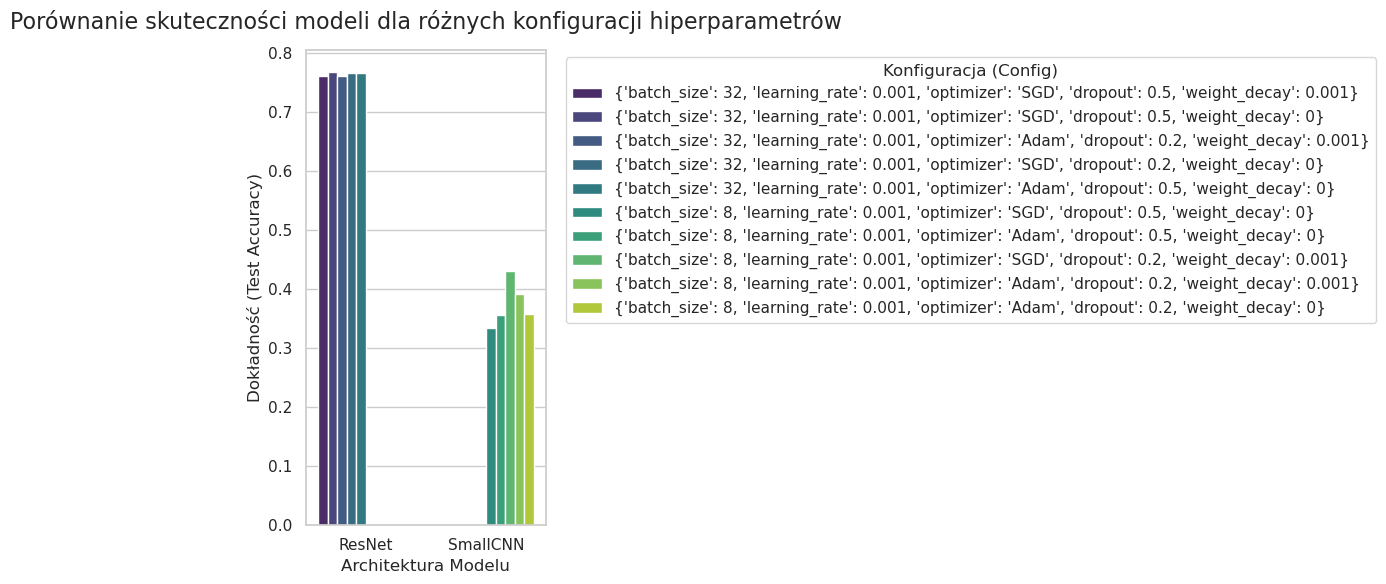

In [13]:
# Ustawiamy globalny, profesjonalny styl dla wszystkich wykresów
sns.set_theme(style="whitegrid", palette="muted")

# =====================================================================
# WYKRES 1: Porównanie konfiguracji (Hiperparametry)
# =====================================================================
def plot_configs(df):
    plt.figure(figsize=(12, 6))
    
    # Tworzymy wykres słupkowy. Użyjemy ostatecznego 'accuracy' (testowego) z ramki.
    ax = sns.barplot(
        data=df, 
        x="model", 
        y="accuracy", 
        hue="config", 
        palette="viridis"
    )
    
    plt.title("Porównanie skuteczności modeli dla różnych konfiguracji hiperparametrów", fontsize=16, pad=15)
    plt.xlabel("Architektura Modelu", fontsize=12)
    plt.ylabel("Dokładność (Test Accuracy)", fontsize=12)
    
    # Wyrzucamy legendę poza wykres
    plt.legend(title="Konfiguracja (Config)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("wykres_1_konfiguracje.png", dpi=300)
    plt.show()

plot_configs(configs_results)


In [ ]:
# =====================================================================
# WYKRES 2: Wpływ technik augmentacji
# =====================================================================
def plot_augmentations(df):
    plt.figure(figsize=(12, 6))
    
    # Zgrupowany wykres słupkowy dla różnych typów augmentacji
    ax = sns.barplot(
        data=df, 
        x="model", 
        y="test_accuracy", 
        hue="augmentation", 
        palette="Set2" # Inna paleta, żeby wykresy w raporcie się odróżniały
    )
    
    plt.title("Wpływ technik augmentacji danych na skuteczność modeli", fontsize=16, pad=15)
    plt.xlabel("Architektura Modelu", fontsize=12)
    plt.ylabel("Dokładność (Test Accuracy)", fontsize=12)
    
    plt.legend(title="Technika Augmentacji", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("wykres_2_augmentacje.png", dpi=300)
    plt.show()

plot_augmentations(augmentation_results)

In [ ]:
# =====================================================================
# WYKRES 3: Krzywa uczenia Few-Shot Learning (Najciekawszy!)
# =====================================================================
def plot_fewshot(df):
    plt.figure(figsize=(10, 6))
    
    # Dla Few-Shot najlepszy jest wykres liniowy z zaznaczonymi punktami (marker='o')
    ax = sns.lineplot(
        data=df, 
        x="shots", 
        y="test_accuracy", 
        hue="model", 
        marker="o",
        linewidth=2.5,
        markersize=8
    )
    
    plt.title("Krzywa uczenia Few-Shot Learning na zbiorze CINIC-10", fontsize=16, pad=15)
    plt.xlabel("Liczba próbek treningowych na klasę (Shots)", fontsize=12)
    plt.ylabel("Dokładność (Test Accuracy)", fontsize=12)
    
    # KLUCZOWE: Oś X w skali logarytmicznej!
    # Ponieważ testujesz np. 1, 5, 10, a potem 9000, bez skali logarytmicznej 
    # wszystkie małe wartości zleją się w jedną kropkę po lewej stronie.
    plt.xscale('log')
    
    # Ręczne ustawienie etykiet osi X dla czytelności (dostosuj do swoich wartości 'shots')
    shots_values = sorted(df['shots'].unique())
    plt.xticks(shots_values, labels=[str(int(x)) for x in shots_values])
    
    plt.legend(title="Model", loc='lower right') # W few-shot krzywe rosną, więc prawy dolny róg jest zazwyczaj pusty
    plt.tight_layout()
    plt.savefig("wykres_3_fewshot.png", dpi=300)
    plt.show()

plot_fewshot(fewshot_results)

In [ ]:
# =====================================================================
# WYKRES 4: Wrażliwość modeli na hiperparametry (Rozkład 108 konfiguracji)
# =====================================================================
def plot_hyperparameter_distribution(df):
    plt.figure(figsize=(10, 6))
    
    # Wykres wiolinowy pokazuje gęstość (gdzie skupia się najwięcej wyników)
    sns.violinplot(
        data=df, 
        x="model", 
        y="accuracy", 
        hue="model",
        palette="pastel", 
        inner=None, # Wyłączamy domyślne linie w środku, bo dodamy własne punkty
        legend=False
    )
    
    # Nakładamy rój punktów (każda kropka to jedna z Twoich 108 konfiguracji!)
    sns.swarmplot(
        data=df, 
        x="model", 
        y="accuracy", 
        color="black", 
        alpha=0.6, 
        size=4
    )
    
    plt.title("Rozkład dokładności 108 kombinacji hiperparametrów", fontsize=16, pad=15)
    plt.xlabel("Architektura Modelu", fontsize=12)
    plt.ylabel("Dokładność Testowa (Accuracy)", fontsize=12)
    
    plt.tight_layout()
    plt.savefig("wykres_4_rozkad_hiperparametrow.png", dpi=300)
    plt.show()


plot_hyperparameter_distribution(small_data_results)

In [ ]:
# =====================================================================
# WYKRES 5: Top 5 konfiguracji dla każdego modelu (Z paskami błędów!)
# =====================================================================
def plot_top_configs_with_errors(df):
    # Wyciągamy po 5 najlepszych konfiguracji (po kolumnie mean_acc) dla każdego modelu
    top_resnet = df[df['model'] == 'ResNet'].nlargest(5, 'mean_acc')
    top_smallcnn = df[df['model'] == 'SmallCNN'].nlargest(5, 'mean_acc')
    
    # Łączymy je z powrotem w jedną ramkę
    top_configs_df = pd.concat([top_resnet, top_smallcnn])
    
    # Tworzymy etykiety (np. "ResNet (Conf 12)", żeby nie wypisywać całego słownika na osi)
    # Dodajemy sztuczną kolumnę z krótką nazwą do wykresu
    top_configs_df['short_name'] = top_configs_df['model'] + " \n" + top_configs_df['config'].astype(str).str[:15] + "..."
    
    plt.figure(figsize=(12, 7))
    
    # Rysujemy słupki z użyciem kolumny średniej dokładności (mean_acc)
    # Używamy parametru xerr do narysowania wąsów błędu na podstawie odchylenia (std_acc)
    ax = sns.barplot(
        data=top_configs_df,
        y="short_name",  # Wykres poziomy jest lepszy, gdy nazwy są długie
        x="mean_acc",
        hue="model",
        palette="viridis",
        dodge=False      # Słupki jeden pod drugim
    )
    
    # Dodawanie "wąsów" błędu (Error bars) z odchylenia standardowego
    for i, p in enumerate(ax.patches):
        # Omijamy puste słupki (seaborn czasem je tworzy przy dodge=False)
        if p.get_width() == 0:
            continue
            
        # Wyciągamy wartość odchylenia standardowego dla danego słupka
        std_val = top_configs_df.iloc[i]['std_acc']
        width = p.get_width()
        y_pos = p.get_y() + p.get_height() / 2
        
        # Rysujemy czarną linię błędu (mean - std_acc do mean + std_acc)
        plt.plot([width - std_val, width + std_val], [y_pos, y_pos], color='black', lw=1.5)
        # Rysujemy pionowe ograniczniki na końcach wąsów
        plt.plot([width - std_val, width - std_val], [y_pos - 0.1, y_pos + 0.1], color='black', lw=1.5)
        plt.plot([width + std_val, width + std_val], [y_pos - 0.1, y_pos + 0.1], color='black', lw=1.5)

    plt.title("Top 5 Konfiguracji: Średnia dokładność (Mean Acc) \n wraz z odchyleniem standardowym (Std Acc)", fontsize=16, pad=15)
    plt.xlabel("Średnia Dokładność (Mean Accuracy)", fontsize=12)
    plt.ylabel("Model i (skrócona) konfiguracja", fontsize=12)
    
    plt.xlim(0, 1.0) # Zakładam, że accuracy to ułamek 0-1
    plt.tight_layout()
    plt.savefig("wykres_5_top_konfiguracje_errorbars.png", dpi=300)
    plt.show()

plot_top_configs_with_errors(small_data_results)

Rozpakowywanie konfiguracji...


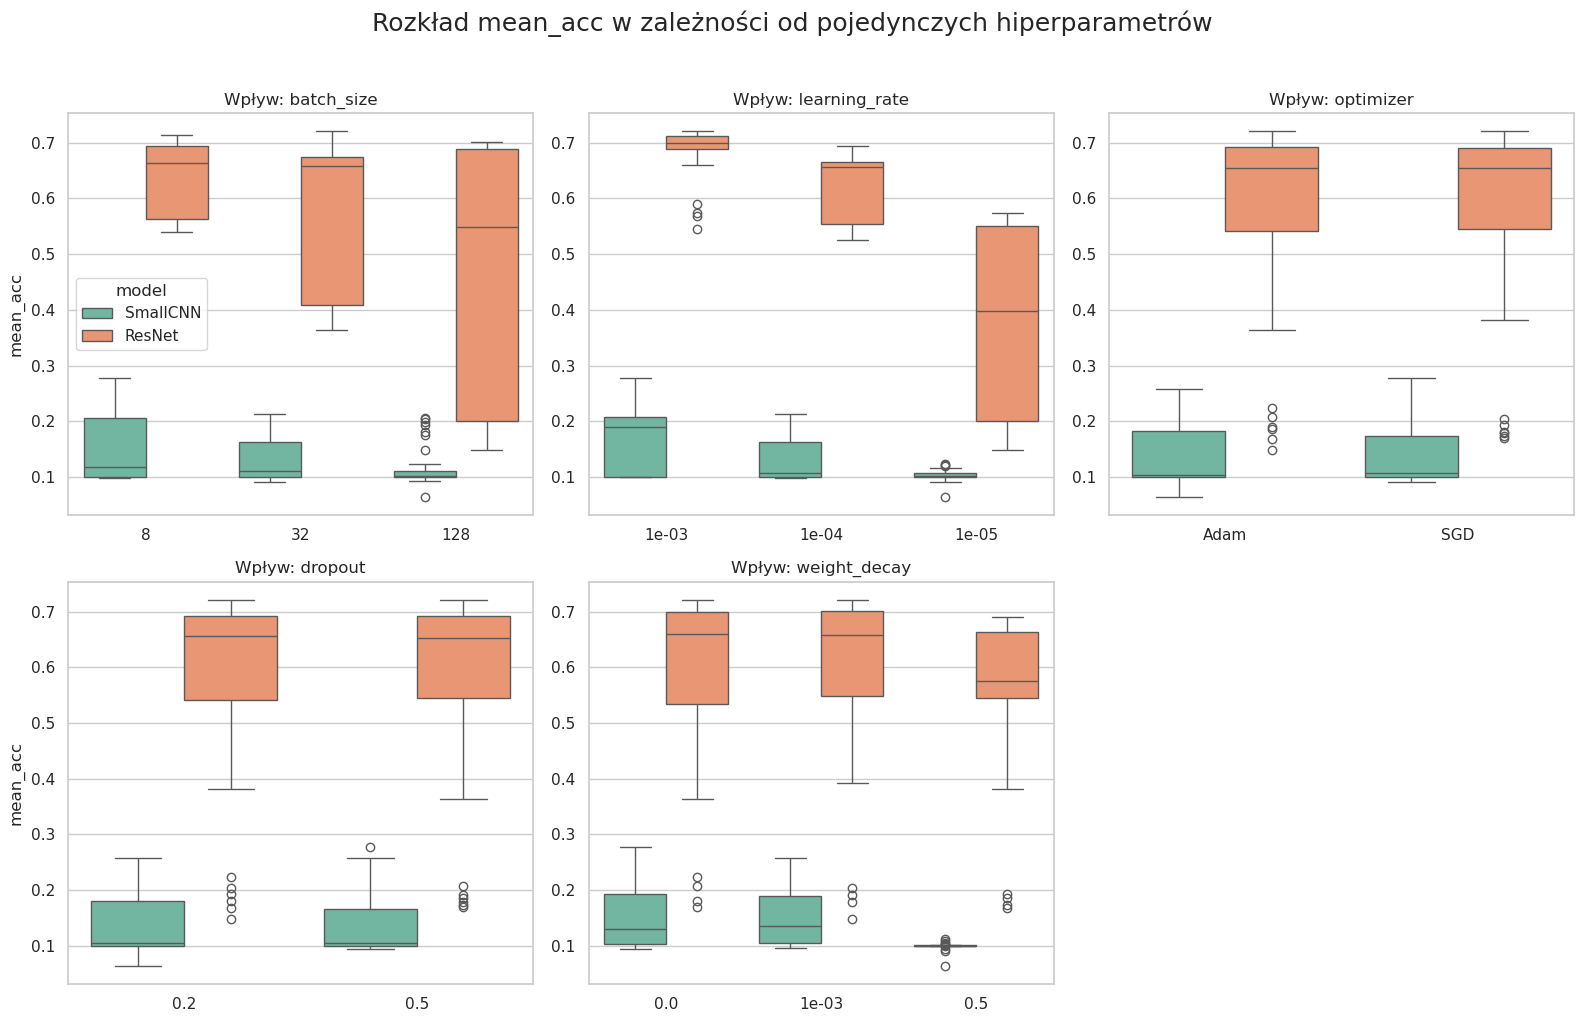

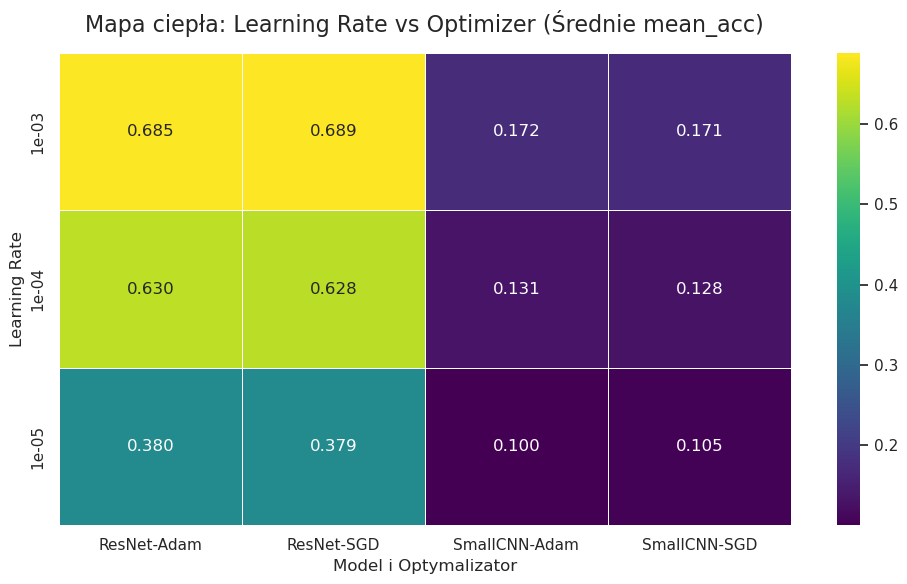

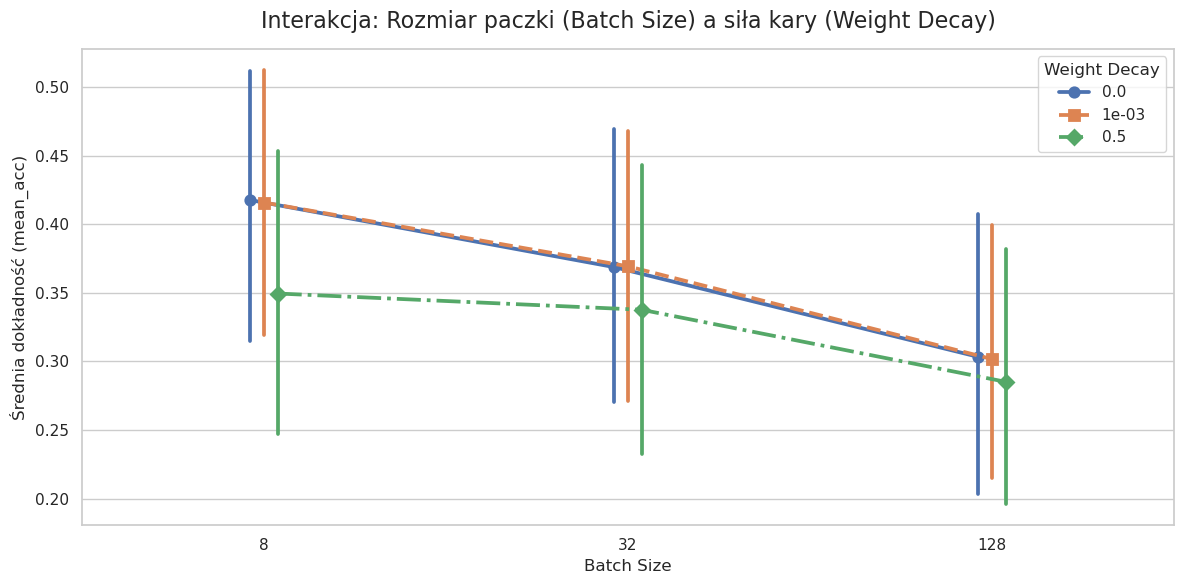

In [14]:
# Ustawienie ładnego stylu
sns.set_theme(style="whitegrid")

def prepare_and_plot_hyperparameters(df, metric="mean_acc"):
    # =====================================================================
    # 1. PRZETWARZANIE DANYCH (Rozpakowanie słownika z tekstu)
    # =====================================================================
    print("Rozpakowywanie konfiguracji...")
    # Zamiana tekstu na słownik
    df['config_dict'] = df['config'].apply(ast.literal_eval)
    
    # Rozwinięcie słownika do osobnych kolumn
    config_expanded = df['config_dict'].apply(pd.Series)
    
    # Połączenie oryginalnej ramki z nowymi kolumnami
    df_expanded = pd.concat([df, config_expanded], axis=1)
    
    # Zamieniamy learning_rate na tekst, żeby wykresy traktowały go jako kategorię (łatwiejsze czytanie osi)
    df_expanded['learning_rate'] = df_expanded['learning_rate'].apply(lambda x: f"{x:.0e}")
    df_expanded['weight_decay'] = df_expanded['weight_decay'].apply(lambda x: f"{x:.0e}" if x < 0.1 and x > 0 else str(x))

    # =====================================================================
    # WYKRES 1: Wpływ pojedynczych parametrów (Main Effects - Boxplots)
    # =====================================================================
    # Tworzymy siatkę wykresów 2x3
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"Rozkład {metric} w zależności od pojedynczych hiperparametrów", fontsize=18, y=1.02)
    
    params = ["batch_size", "learning_rate", "optimizer", "dropout", "weight_decay"]
    axes = axes.flatten() # Spłaszczamy tablicę osi, żeby łatwiej po niej iterować
    
    for i, param in enumerate(params):
        sns.boxplot(
            data=df_expanded, 
            x=param, 
            y=metric, 
            hue="model", 
            ax=axes[i],
            palette="Set2"
        )
        axes[i].set_title(f"Wpływ: {param}", fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel(metric if i % 3 == 0 else "") # Y label tylko dla skrajnych lewych
        
        # Zostawiamy legendę tylko na pierwszym wykresie, żeby nie śmiecić
        if i > 0:
            axes[i].get_legend().remove()
            
    # Usuwamy szósty, pusty wykres
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.savefig("hiperparametry_1_boxplots.png", dpi=300, bbox_inches='tight')
    plt.show()

    # =====================================================================
    # WYKRES 2: Mapa Ciepła (Heatmap) - Najważniejsza interakcja: LR vs Optimizer
    # =====================================================================
    plt.figure(figsize=(10, 6))
    
    # Tworzymy tabelę przestawną (średni wynik dla kombinacji LR i Optymalizatora)
    pivot_df = df_expanded.pivot_table(
        index='learning_rate', 
        columns=['model', 'optimizer'], 
        values=metric, 
        aggfunc='mean'
    )
    
    sns.heatmap(
        pivot_df, 
        annot=True,      # Wypisuje liczby na kwadracikach
        fmt=".3f",       # Format do 3 miejsc po przecinku
        cmap="viridis",  # Świetna kolorystyka od ciemnego do jasnego
        linewidths=.5
    )
    
    plt.title(f"Mapa ciepła: Learning Rate vs Optimizer (Średnie {metric})", fontsize=16, pad=15)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.xlabel("Model i Optymalizator", fontsize=12)
    
    plt.tight_layout()
    plt.savefig("hiperparametry_2_heatmap.png", dpi=300)
    plt.show()

    # =====================================================================
    # WYKRES 3: Wykres interakcji punktowej (Pointplot) - Batch Size vs Regularization
    # =====================================================================
    plt.figure(figsize=(12, 6))
    
    # Pointplot genialnie pokazuje trendy i interakcje między 3 zmiennymi
    sns.pointplot(
        data=df_expanded, 
        x="batch_size", 
        y=metric, 
        hue="weight_decay", 
        dodge=True,    # Rozsuwa linie, żeby na siebie nie nachodziły
        markers=["o", "s", "D"],
        linestyles=["-", "--", "-."]
    )
    
    plt.title(f"Interakcja: Rozmiar paczki (Batch Size) a siła kary (Weight Decay)", fontsize=16, pad=15)
    plt.xlabel("Batch Size", fontsize=12)
    plt.ylabel(f"Średnia dokładność ({metric})", fontsize=12)
    plt.legend(title="Weight Decay")
    
    plt.tight_layout()
    plt.savefig("hiperparametry_3_pointplot.png", dpi=300)
    plt.show()

prepare_and_plot_hyperparameters(small_data_results, metric="mean_acc")